In [4]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap, Normalize
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata.txt'

In [5]:


df_best = pd.read_csv('tables/best_ms_method_per_model.csv')

df_m2100 = pd.read_csv('./tables/averegeshelfmelt_2100.csv')
df_m2200 = pd.read_csv('./tables/averegeshelfmelt_2200.csv')
df_m2300 = pd.read_csv('./tables/averegeshelfmelt_2300.csv')


df_bmb2100 = pd.read_csv('./tables/totalshelfmelt_2100.csv')
df_bmb2200 = pd.read_csv('./tables/totalshelfmelt_2200.csv')
df_bmb2300 = pd.read_csv('./tables/totalshelfmelt_2300.csv')
                         
df_dslr2100 = pd.read_csv('./tables/dslc_anom_2100.csv')
df_dslr2200 = pd.read_csv('./tables/dslc_anom_2200.csv')
df_dslr2300 = pd.read_csv('./tables/dslc_anom_2300.csv')

df_tf2100 = pd.read_csv('./tables/thermalforcing_2100.csv')
df_tf2200 = pd.read_csv('./tables/thermalforcing_2200.csv')
df_tf2300 = pd.read_csv('./tables/thermalforcing_2300.csv')

df_iareafl2100 = pd.read_csv('./tables/iareafl_2100.csv')
df_iareafl2200 = pd.read_csv('./tables/iareafl_2200.csv')
df_iareafl2300 = pd.read_csv('./tables/iareafl_2300.csv')

df_iareafl2100_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2100.csv')
df_iareafl2200_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2300.csv')
df_iareafl2300_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2300.csv')


dfds = [
    df_m2100 ,
df_m2200 ,
df_m2300 ,
df_bmb2100,
df_bmb2200 ,
df_bmb2300  ,                     
df_tf2100 ,
df_tf2200 ,
df_tf2300 ,
df_iareafl2100, 
df_iareafl2200 ,
df_iareafl2300 ,
df_iareafl2100_change ,
df_iareafl2200_change,
df_iareafl2300_change,


]

for df_ms in dfds:
    df_ms['WestAntarctica'] = df_ms['region_1']
    df_ms['EastAntarctica'] = df_ms['region_2']
    df_ms['Peninsula'] = df_ms['region_3']
    
regions = ['AIS',
 'WestAntarctica',
 'EastAntarctica',
 'Peninsula',
           'Amundsen',
 'Ross',
 'FilchnerRonne']

In [15]:
df_best.iloc[27].values[5::2]

array([21.93375810266477, 14.991803025189006, 10.972687269632344,
       19.879882811651644, 14.650908271837272, 22.328212350469727,
       6.261788112476971], dtype=object)

In [13]:
df_best

,Unnamed: 0,Model,mean-error,method,parameterization,melt_sensetivity_AIS,melt_sensetivity_intercept_AIS,melt_sensetivity_Amundsen,melt_sensetivity_intercept_Amundsen,melt_sensetivity_Ross,melt_sensetivity_intercept_Ross,melt_sensetivity_FilchnerRonne,melt_sensetivity_intercept_FilchnerRonne,melt_sensetivity_WestAntarctica,melt_sensetivity_intercept_WestAntarctica,melt_sensetivity_EastAntarctica,melt_sensetivity_intercept_EastAntarctica,melt_sensetivity_Peninsula,melt_sensetivity_intercept_Peninsula
0,0,DC_ISSM,1.959097,df_maxbmb,Quad. Non-local,3.895959,-1.398919,9.183323,-1.582275,3.720531,-1.701558,4.748896,-2.198766,4.348727,-1.900654,4.213586,-1.479211,1.818610,-0.314251
1,1,IGE_ElmerIce,2.965707,df_maxbmb,PICO,2.110396,0.296224,2.831167,9.863159,1.744727,-0.422262,2.038370,-1.195653,1.691065,0.276987,2.872538,-0.184109,4.932470,-1.361450
2,2,ILTS_SICOPOLIS,2.761296,df_maxbmb_2k,Quad. Non-local,5.297964,-1.956686,12.734657,-0.760224,3.574502,-1.451954,5.267966,-2.593836,5.262305,-1.845908,5.079944,-1.745513,3.482976,-1.478106
3,3,LSCE_GRISLI2,3.233607,df_maxbmb_2100,Quad. Non-local,5.947404,-2.765166,12.105475,-1.573739,3.919317,-1.750611,5.475569,-2.567570,5.648605,-2.550484,5.641786,-2.252251,4.520818,-3.269863
4,4,LSCE_GRISLI,3.398583,df_maxbmb_2100,Quad. Non-local,6.106663,-2.900344,12.657794,-2.433293,3.930029,-1.769565,5.561223,-2.607899,5.732383,-2.679052,5.717830,-2.309375,4.130935,-2.908215
5,5,NCAR_CISM1,2.301010,df_maxbmb_2k,Quad. Non-local,4.281649,-1.686388,5.717034,-6.741590,3.152983,-1.302097,4.783804,-2.478397,4.473627,-1.943489,4.243672,-1.596607,2.048020,0.546405
6,6,NCAR_CISM2,2.602965,df_maxbmb_2k,Quad. Local,6.147876,-2.138430,7.597750,-2.689526,4.204205,-1.254059,7.186805,-2.830221,6.507816,-2.319541,6.134695,-1.947057,2.775852,-0.437819
7,7,NORCE_CISM2-MAR364-ERA-t1,4.299751,df_maxbmb_2k,Quad. Non-local Slope,5.163648,-2.406684,9.607826,-7.581897,1.932915,-0.782667,6.097992,-3.955713,5.214456,-2.647558,5.409420,-2.233244,3.058081,-1.190778
8,8,NORCE_CISM3-MAR364-ERA-t1-local,2.437814,df_maxbmb_2k,Quad. Local,3.880806,-1.385036,3.755640,-1.310094,3.018316,-0.916247,4.714712,-2.092414,4.250863,-1.659539,3.721768,-1.169245,2.347345,-0.658852
9,9,NORCE_CISM3-MAR364-ERA-t1-nonlocal,2.167126,df_maxbmb_2k,Quad. Non-local,4.038875,-1.314914,4.557420,-2.332686,3.380904,-0.998023,4.730729,-1.905328,4.431299,-1.599052,3.942529,-1.137309,2.628339,-0.691143


In [3]:
param_u =np.unique(df_best['parameterization'])
marker_u = ['^','v','*','s','P','p']
dic_marker = {}
for i,key in enumerate(param_u):
    dic_marker[key]= marker_u[i]
markers = []
marker_nomodel=[]
msk = df_best.Model.values != 'VUW_PISM2_s1'
for key in df_best['parameterization']:
    markers.append(dic_marker[key])

for key in df_best['parameterization'][msk]:
    marker_nomodel.append(dic_marker[key])

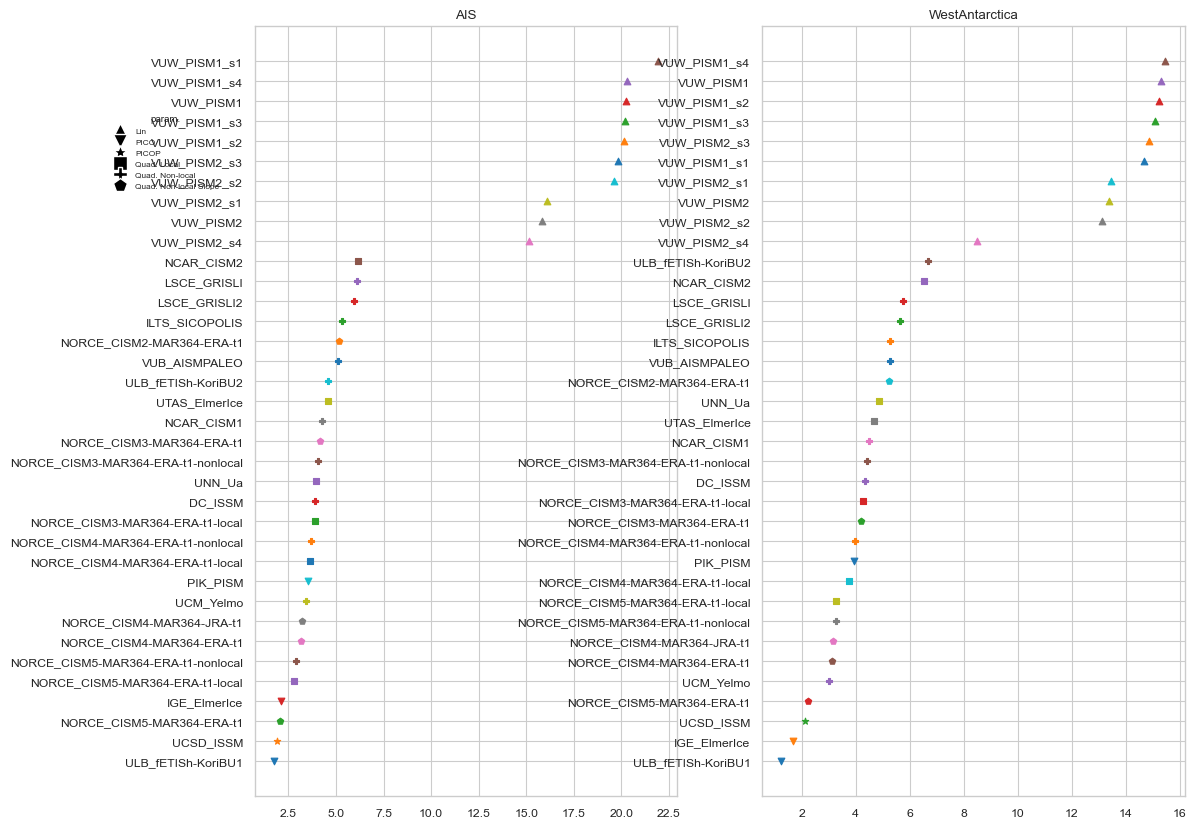

In [34]:
f,ax2 = plt.subplots(1,2,figsize = (12,10))
models = df_best.Model
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_marker.items()]

for i,col in enumerate(regions[:2]):
    ax = ax2[i]
    ms = df_best[f'melt_sensetivity_{col}'].values.copy()
    idx  = np.argsort(ms).copy()
    for j,x in enumerate(idx):
        ax.scatter(ms[x],j,marker = markers[x])
    ax.set_yticks(np.arange(len(idx)))
    ax.set_yticklabels(models[idx])
    ax.set_title(col)
f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


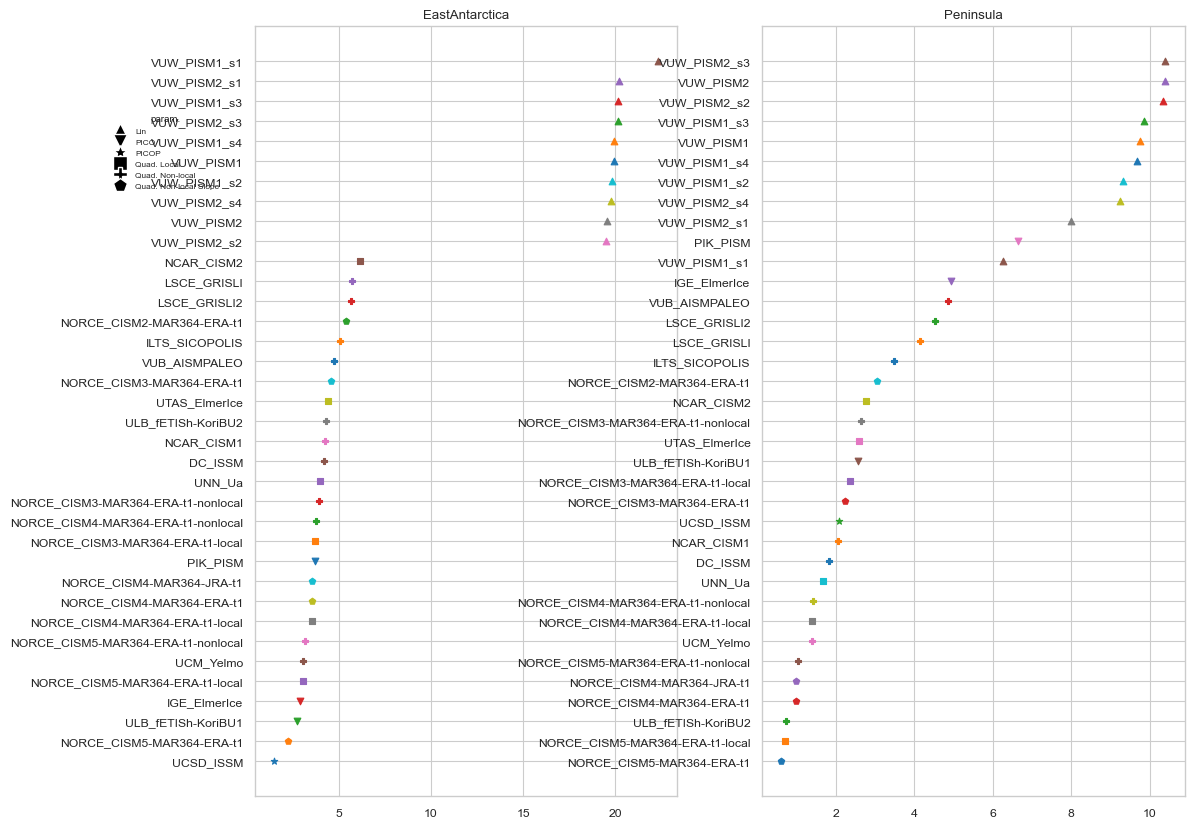

In [35]:
f,ax2 = plt.subplots(1,2,figsize = (12,10))
models = df_best.Model
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_marker.items()]

for i,col in enumerate(regions[2:4]):
    ax = ax2[i]
    ms = df_best[f'melt_sensetivity_{col}'].values.copy()
    idx  = np.argsort(ms).copy()
    for j,x in enumerate(idx):
        ax.scatter(ms[x],j,marker = markers[x])
    ax.set_yticks(np.arange(len(idx)))
    ax.set_yticklabels(models[idx])
    ax.set_title(col)
    
f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


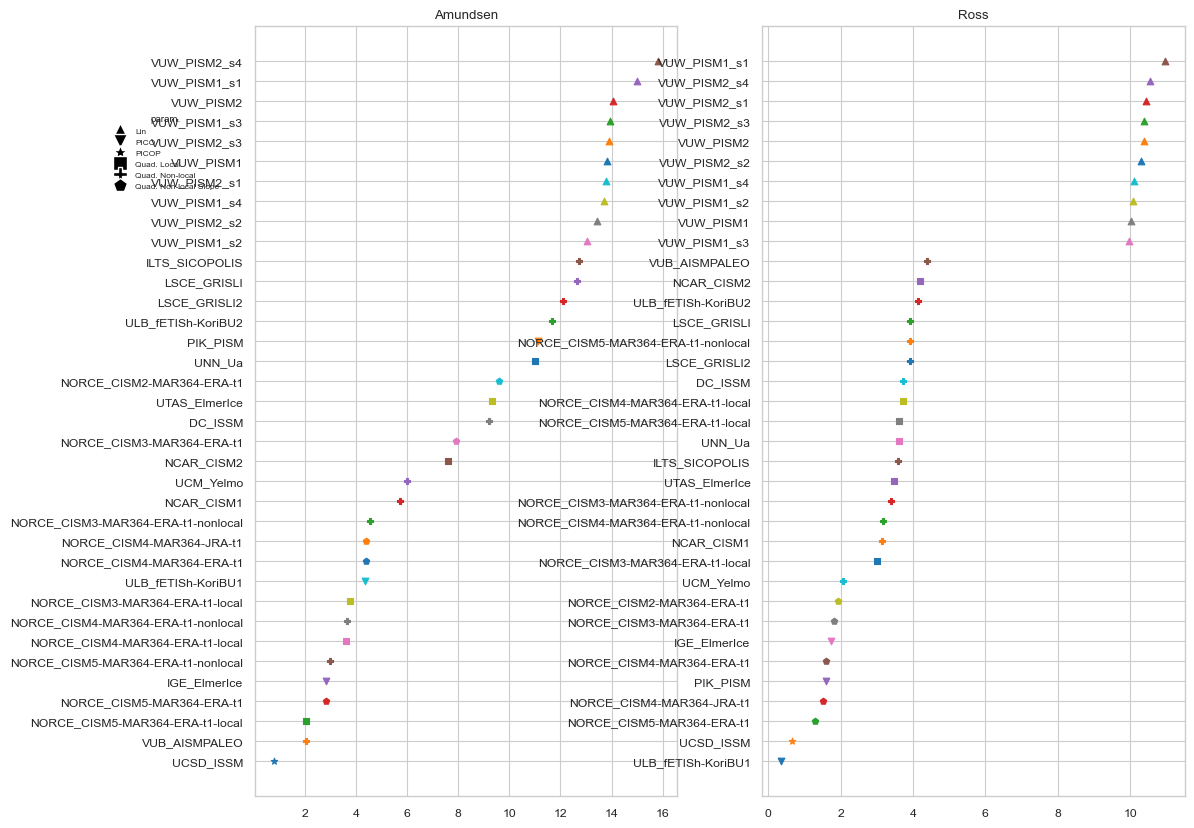

In [36]:
f,ax2 = plt.subplots(1,2,figsize = (12,10))
models = df_best.Model
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_marker.items()]

for i,col in enumerate(regions[4:6]):
    ax = ax2[i]
    ms = df_best[f'melt_sensetivity_{col}'].values.copy()
    idx  = np.argsort(ms).copy()
    for j,x in enumerate(idx):
        ax.scatter(ms[x],j,marker = markers[x])
    ax.set_yticks(np.arange(len(idx)))
    ax.set_yticklabels(models[idx])
    ax.set_title(col)
    
f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


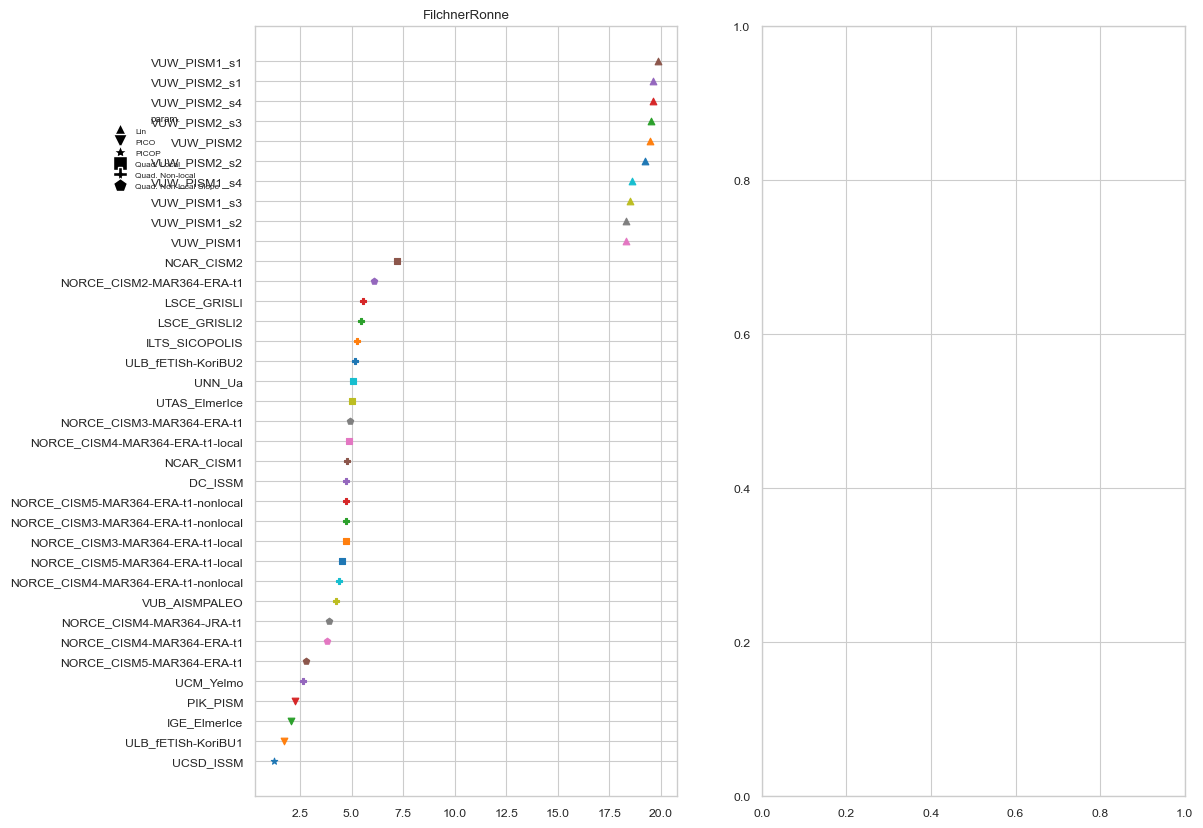

In [37]:
f,ax2 = plt.subplots(1,2,figsize = (12,10))
models = df_best.Model
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_marker.items()]

for i,col in enumerate(regions[6:]):
    ax = ax2[i]
    ms = df_best[f'melt_sensetivity_{col}'].values.copy()
    idx  = np.argsort(ms).copy()
    for j,x in enumerate(idx):
        ax.scatter(ms[x],j,marker = markers[x])
    ax.set_yticks(np.arange(len(idx)))
    ax.set_yticklabels(models[idx])
    ax.set_title(col)
    
f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


In [4]:
df_best.parameterization

0           Quad. Non-local
1                      PICO
2           Quad. Non-local
3           Quad. Non-local
4           Quad. Non-local
5           Quad. Non-local
6               Quad. Local
7     Quad. Non-local Slope
8               Quad. Local
9           Quad. Non-local
10    Quad. Non-local Slope
11              Quad. Local
12          Quad. Non-local
13    Quad. Non-local Slope
14    Quad. Non-local Slope
15              Quad. Local
16          Quad. Non-local
17    Quad. Non-local Slope
18                     PICO
19          Quad. Non-local
20                    PICOP
21                     PICO
22          Quad. Non-local
23              Quad. Local
24              Quad. Local
25          Quad. Non-local
26                      Lin
27                      Lin
28                      Lin
29                      Lin
30                      Lin
31                      Lin
32                      Lin
33                      Lin
34                      Lin
35                  

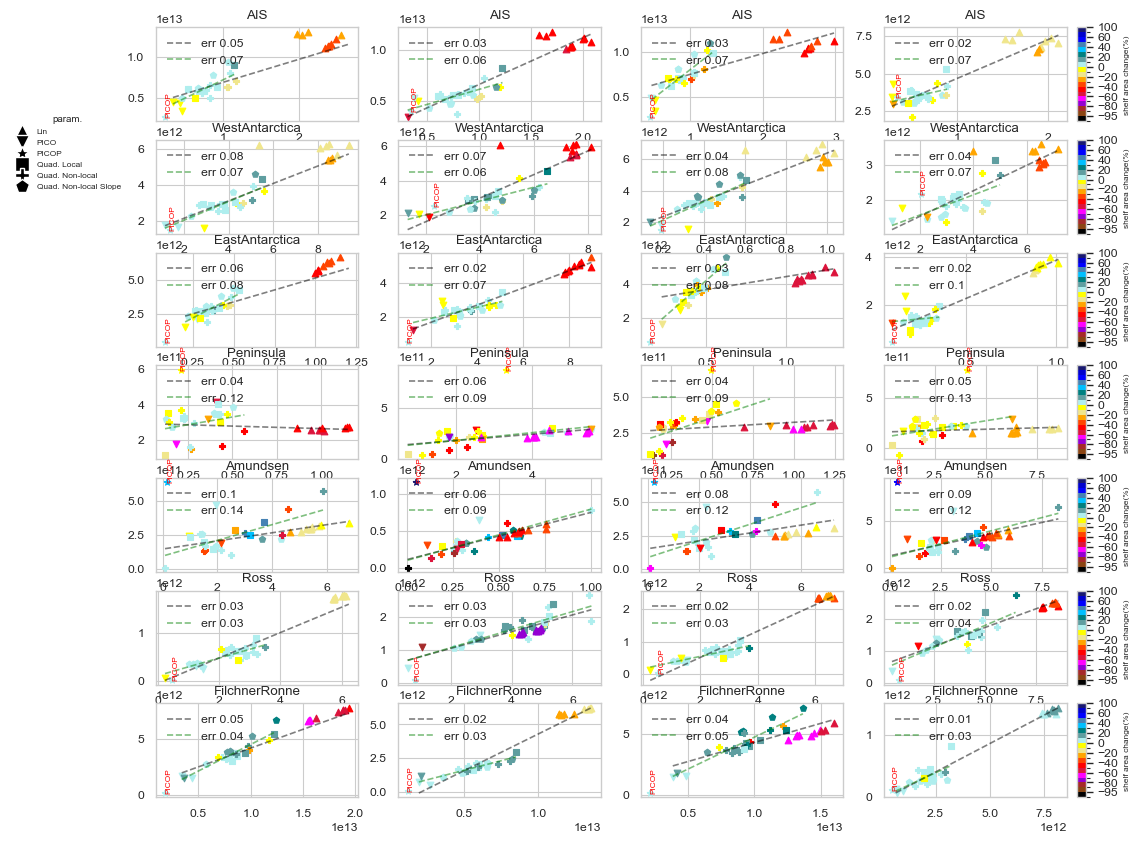

In [5]:
f,ax2 = plt.subplots(7,4,figsize = (12,10))
segments = [-100, -95, -90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 100]
colors = ['black', 'saddlebrown', 'brown', 'darkviolet', 'fuchsia' ,'crimson', 'red', 'orangered' ,'orange', 'gold',
          'khaki', 'yellow', 'paleturquoise', 'cadetblue', 'teal', 'deepskyblue', 'steelblue', 'blue',
          'mediumblue', 'darkblue','midnightblue']
# Create a colormap from the specified colors
cmap = ListedColormap(colors)
norm = BoundaryNorm(segments, len(colors))
# Create custom legend elements



#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_marker.items()]

for i,col in enumerate(regions):
# for i,col in enumerate(['Amundsen']):
    
    xm = df_best[f'melt_sensetivity_{col}'].values
    dftemp = df_tf2100
    dftemp2 = df_iareafl2100
    dftemp3 = df_bmb2100
    dftemp4 = df_iareafl2100_change
    
  
    for j,exp in enumerate(expnames):
        ax = ax2[i,j]
  
        ax.set_title(col)
    
        
        
        x3 =dftemp[dftemp['Experiment' ]== exp][col].values
        x2 =dftemp2[dftemp2['Experiment' ]== exp][col].values
        y3 =dftemp3[dftemp3['Experiment' ]== exp][col].values
        sc =dftemp4[dftemp4['Experiment' ]== exp][col].values

        x = xm*x2*x3
       
        
        Models = dftemp3[dftemp3['Experiment' ]== exp].Model.values
        models = Models.astype(str)        
        
        if (exp == 'expAE02') :
            msk = Models != 'VUW_PISM1_s1'
            for k in range(len(Models[ msk])):
#                 scatter =ax.scatter(x[k],y3[k],marker = markers[k],c=sc[k], cmap=cmap, norm =norm)
                scatter =ax.scatter(x[msk][k],y3[msk][k],marker = marker_nomodel[k],c=sc[msk][k], cmap=cmap, norm = norm)
        else:
            for k in range(len(Models)):
                scatter =ax.scatter(x[k],y3[k],marker = markers[k],c=sc[k], cmap=cmap, norm =norm)
#             ax3.scatter(x,sc,marker = '.',color = 'orange')
            
        model ='UCSD_ISSM'
        m_paleo = Models == model
        mnan1 = np.isnan(x)
        mnan2 = np.isnan(y3)
        mnan = mnan1 |mnan2 | m_paleo
        
        ax.scatter(x[m_paleo],y3[m_paleo],marker = '+',c=sc[m_paleo], cmap=cmap, norm = norm)
        ax.annotate('PICOP',(x[m_paleo],y3[m_paleo]),color= 'red',rotation = 90, fontsize =6)
        slope, intercept, r, p, se = linregress(x[~mnan], y3[~mnan])
        x_even = np.linspace(x[~mnan].min(),x[~mnan].max(),100)
        ax.plot(x_even,x_even*slope + intercept, linestyle ='dashed',color = 'black',alpha = 0.5,label = f'err {np.round(se,2)}')
        mask = ~np.char.startswith(models[~mnan], 'VUW_PISM')

        slope, intercept, r, p, se = linregress(x[~mnan][mask], y3[~mnan][mask])
        x_even = np.linspace(x[~mnan][mask].min(),x[~mnan][mask].max(),100)
        ax.plot(x_even,x_even*slope + intercept, linestyle ='dashed',color = 'green',alpha = 0.5,label = f'err {np.round(se,2)}')
        
        
        ax.legend(frameon = False,loc = 2)
    divider = make_axes_locatable(ax2[i, -1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
# cbar = f.colorbar(scatter, ax=ax2[-1,2], orientation='horizontal', fraction=0.02, pad=0.1)
    cbar = f.colorbar(scatter, cax=cax)
    cbar.set_label('shelf area change(%) ',fontsize = 6)

f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)
    #     ax[i].plot(Models.index,y)
#     ax[i].set_title(col)
# ax[i].set_xticks(Models.index)
        
# ax[i].set_xticklabels(Models, rotation=90)

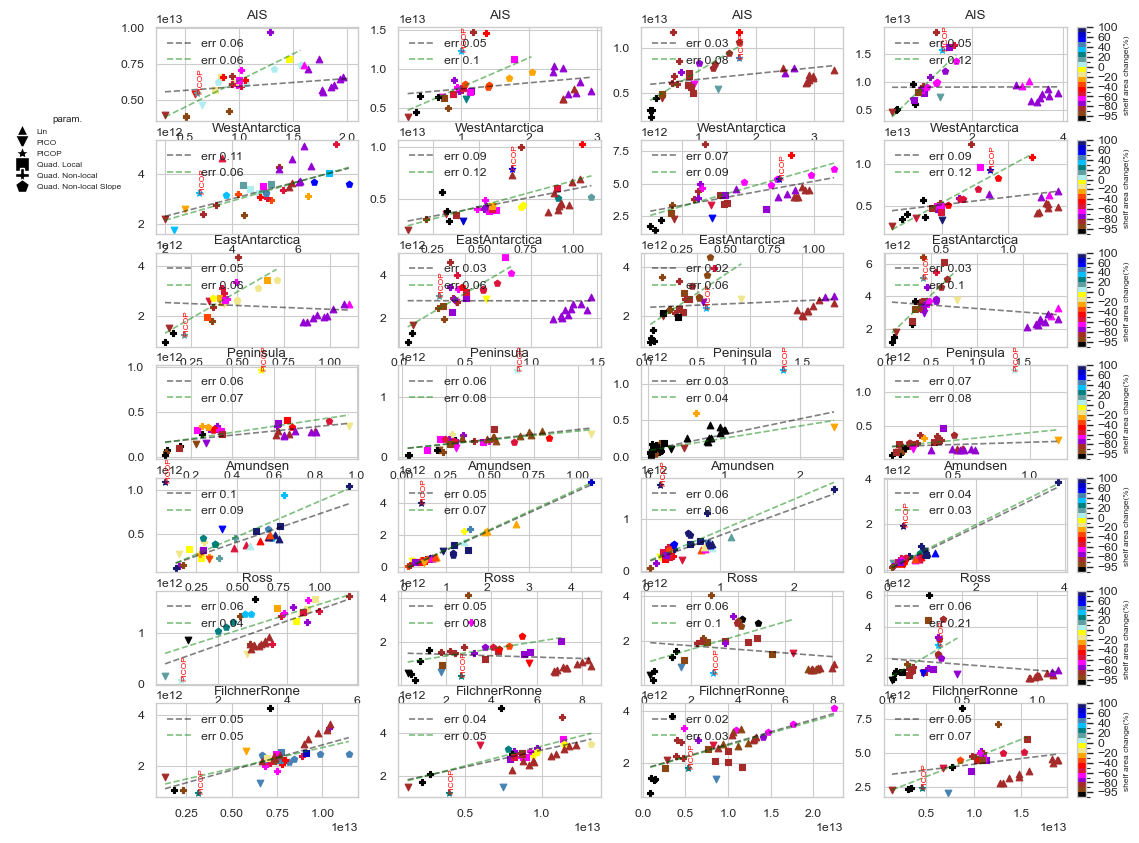

In [6]:
f,ax2 = plt.subplots(7,4,figsize = (12,10))
segments = [-100, -95, -90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 100]
colors = ['black', 'saddlebrown', 'brown', 'darkviolet', 'fuchsia' ,'crimson', 'red', 'orangered' ,'orange', 'gold',
          'khaki', 'yellow', 'paleturquoise', 'cadetblue', 'teal', 'deepskyblue', 'steelblue', 'blue',
          'mediumblue', 'darkblue','midnightblue']
# Create a colormap from the specified colors
cmap = ListedColormap(colors)
norm = BoundaryNorm(segments, len(colors))
# Create custom legend elements



#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_marker.items()]

for i,col in enumerate(regions):
# for i,col in enumerate(['Amundsen']):
    
    xm = df_best[f'melt_sensetivity_{col}'].values
    dftemp = df_tf2200
    dftemp2 = df_iareafl2200
    dftemp3 = df_bmb2200
    dftemp4 = df_iareafl2200_change
    
  
    for j,exp in enumerate(expnames):
        ax = ax2[i,j]
  
        ax.set_title(col)
    
        
        
        x3 =dftemp[dftemp['Experiment' ]== exp][col].values
        x2 =dftemp2[dftemp2['Experiment' ]== exp][col].values
        y3 =dftemp3[dftemp3['Experiment' ]== exp][col].values
        sc =dftemp4[dftemp4['Experiment' ]== exp][col].values

        x = xm*x2*x3
       
        
        Models = dftemp3[dftemp3['Experiment' ]== exp].Model.values
        models = Models.astype(str)        
        
        if (exp == 'expAE02') :
            msk = Models != 'VUW_PISM1_s1'
            for k in range(len(Models[ msk])):
#                 scatter =ax.scatter(x[k],y3[k],marker = markers[k],c=sc[k], cmap=cmap, norm =norm)
                scatter =ax.scatter(x[msk][k],y3[msk][k],marker = marker_nomodel[k],c=sc[msk][k], cmap=cmap, norm = norm)
        else:
            for k in range(len(Models)):
                scatter =ax.scatter(x[k],y3[k],marker = markers[k],c=sc[k], cmap=cmap, norm =norm)
#             ax3.scatter(x,sc,marker = '.',color = 'orange')
            
        model ='UCSD_ISSM'
        m_paleo = Models == model
        mnan1 = np.isnan(x)
        mnan2 = np.isnan(y3)
        mnan = mnan1 |mnan2 | m_paleo
        
        ax.scatter(x[m_paleo],y3[m_paleo],marker = '+',c=sc[m_paleo], cmap=cmap, norm = norm)
        ax.annotate('PICOP',(x[m_paleo],y3[m_paleo]),color= 'red',rotation = 90, fontsize =6)
        slope, intercept, r, p, se = linregress(x[~mnan], y3[~mnan])
        x_even = np.linspace(x[~mnan].min(),x[~mnan].max(),100)
        ax.plot(x_even,x_even*slope + intercept, linestyle ='dashed',color = 'black',alpha = 0.5,label = f'err {np.round(se,2)}')
        mask = ~np.char.startswith(models[~mnan], 'VUW_PISM')

        slope, intercept, r, p, se = linregress(x[~mnan][mask], y3[~mnan][mask])
        x_even = np.linspace(x[~mnan][mask].min(),x[~mnan][mask].max(),100)
        ax.plot(x_even,x_even*slope + intercept, linestyle ='dashed',color = 'green',alpha = 0.5,label = f'err {np.round(se,2)}')
        
        
        ax.legend(frameon = False,loc = 2)
    divider = make_axes_locatable(ax2[i, -1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
# cbar = f.colorbar(scatter, ax=ax2[-1,2], orientation='horizontal', fraction=0.02, pad=0.1)
    cbar = f.colorbar(scatter, cax=cax)
    cbar.set_label('shelf area change(%) ',fontsize = 6)

f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)
    #     ax[i].plot(Models.index,y)
#     ax[i].set_title(col)
# ax[i].set_xticks(Models.index)
        
# ax[i].set_xticklabels(Models, rotation=90)

In [7]:
f,ax2 = plt.subplots(7,4,figsize = (12,10))
segments = [-100, -95, -90, -80, -70, -60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 100]
colors = ['black', 'saddlebrown', 'brown', 'darkviolet', 'fuchsia' ,'crimson', 'red', 'orangered' ,'orange', 'gold',
          'khaki', 'yellow', 'paleturquoise', 'cadetblue', 'teal', 'deepskyblue', 'steelblue', 'blue',
          'mediumblue', 'darkblue','midnightblue']
# Create a colormap from the specified colors
cmap = ListedColormap(colors)
norm = BoundaryNorm(segments, len(colors))
# Create custom legend elements



#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_marker.items()]

for i,col in enumerate(regions):
# for i,col in enumerate(['Amundsen']):
    
    xm = df_best[f'melt_sensetivity_{col}'].values
    dftemp = df_tf2300
    dftemp2 = df_iareafl2300
    dftemp3 = df_bmb2300
    dftemp4 = df_iareafl2300_change
    
  
    for j,exp in enumerate(expnames):
        ax = ax2[i,j]
  
        ax.set_title(col)
    
        
        
        x3 =dftemp[dftemp['Experiment' ]== exp][col].values
        x2 =dftemp2[dftemp2['Experiment' ]== exp][col].values
        y3 =dftemp3[dftemp3['Experiment' ]== exp][col].values
        sc =dftemp4[dftemp4['Experiment' ]== exp][col].values

        x = xm*x2*x3
       
        
        Models = dftemp3[dftemp3['Experiment' ]== exp].Model.values
        models = Models.astype(str)        
        
        if (exp == 'expAE02') :
            msk = Models != 'VUW_PISM1_s1'
            for k in range(len(Models[ msk])):
#                 scatter =ax.scatter(x[k],y3[k],marker = markers[k],c=sc[k], cmap=cmap, norm =norm)
                scatter =ax.scatter(x[msk][k],y3[msk][k],marker = marker_nomodel[k],c=sc[msk][k], cmap=cmap, norm = norm)
        else:
            for k in range(len(Models)):
                scatter =ax.scatter(x[k],y3[k],marker = markers[k],c=sc[k], cmap=cmap, norm =norm)
#             ax3.scatter(x,sc,marker = '.',color = 'orange')
            
        model ='UCSD_ISSM'
        m_paleo = Models == model
        mnan1 = np.isnan(x)
        mnan2 = np.isnan(y3)
        mnan = mnan1 |mnan2 | m_paleo
        
        ax.scatter(x[m_paleo],y3[m_paleo],marker = '+',c=sc[m_paleo], cmap=cmap, norm = norm)
        ax.annotate('PICOP',(x[m_paleo],y3[m_paleo]),color= 'red',rotation = 90, fontsize =6)
        slope, intercept, r, p, se = linregress(x[~mnan], y3[~mnan])
        x_even = np.linspace(x[~mnan].min(),x[~mnan].max(),100)
        ax.plot(x_even,x_even*slope + intercept, linestyle ='dashed',color = 'black',alpha = 0.5,label = f'err {np.round(se,2)}')
        mask = ~np.char.startswith(models[~mnan], 'VUW_PISM')

        slope, intercept, r, p, se = linregress(x[~mnan][mask], y3[~mnan][mask])
        x_even = np.linspace(x[~mnan][mask].min(),x[~mnan][mask].max(),100)
        ax.plot(x_even,x_even*slope + intercept, linestyle ='dashed',color = 'green',alpha = 0.5,label = f'err {np.round(se,2)}')
        
        
        ax.legend(frameon = False,loc = 2)
    divider = make_axes_locatable(ax2[i, -1])
    cax = divider.append_axes("right", size="5%", pad=0.1)
# cbar = f.colorbar(scatter, ax=ax2[-1,2], orientation='horizontal', fraction=0.02, pad=0.1)
    cbar = f.colorbar(scatter, cax=cax)
    cbar.set_label('shelf area change(%) ',fontsize = 6)

f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)
    #     ax[i].plot(Models.index,y)
#     ax[i].set_title(col)
# ax[i].set_xticks(Models.index)
        
# ax[i].set_xticklabels(Models, rotation=90)

### once we loose to much shelf this relations ship does not hold


In [8]:
f,ax2 = plt.subplots(4,1,figsize = (12,10))
# for i,col in enumerate(colum_with_vals[-7:-6]):
for i,col in enumerate(['Ross']):
    
    xm = df_best[f'melt_sensetivity_{col}'].values
    dftemp = df_tf2300
    dftemp2 = df_iareafl2300
    dftemp3 = df_bmb2300
  
    for j,exp in enumerate(expnames):
        ax = ax2[j]
        ax.set_title(col)
    
        
        
        x3 =dftemp[dftemp['Experiment' ]== exp][col].values
        x2 =dftemp2[dftemp2['Experiment' ]== exp][col].values
        y3 =dftemp3[dftemp3['Experiment' ]== exp][col].values
        x = xm*x2*x3
        ax.scatter(x,y3,marker = '.')
        for k in range(len(y3)):
            ax.annotate(dftemp3[dftemp3['Experiment' ]== exp].Model.values[k],(x[k],y3[k]),rotation = 90,fontsize =7)
        
    #     ax[i].plot(Models.index,y)
#     ax[i].set_title(col)
# ax[i].set_xticks(Models.index)
        
# ax[i].set_xticklabels(Models, rotation=90)

In [9]:
dftemp3

#### Grouping things by melt sensetiviy

In [10]:
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'

#*************************** choose variable,factor and path


variable2 = 'shelfmelt'
factor = -1* 365.25 * 24 * 3600/900
pth = pth_helene


variable = 'iareafl'




variable3 = 'thermalforcing'
pth3 = pth_imip6hack
# variable2 = 'iareafl'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata.txt'
def get_model(string,exp):
    return string.split('/')[-1].split('AIS_')[-1].split('_'+str(exp))[0]

# Generate loop_info DataFrame
models=[]
paths =[]
exps =[]
for exp in expnames:
    lst = glob.glob(pth_helene+f'{exp}/shelfmelt/*.nc')
    lst.sort()

    for name in lst:
        model = get_model(name,exp)
        if model in removeFileID:
            continue
        else:
            models.append(model)
            paths.append(name)
            exps.append(exp)
df = pd.DataFrame({ 'Experiment': exps,'Model': models, 'Path': paths}) 
regions_keys ={}
regions_keys['AIS'] = ['']
regions_keys['WestAntarctica']=['_region_1']
regions_keys['EastAntarctica']=['_region_2']
regions_keys['Peninsula']=['_region_3']
regions_keys['Amundsen']=['_sector_4']
regions_keys['Ross']=['_sector_2','_sector_6',]
regions_keys['FilchnerRonne']= ['_sector_5','_sector_11']


In [11]:
colors = ['blue','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
Models = df_best.Model.values
for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values
    xm = xmi.copy()
    print('max',xm.max())
    print('min',xm.min())
    
    
    
    xm.sort()
    xm_high = xm[-10:]
    xm_low = xm[:5]
    xm_mid = xm[5:10]
    for j,ms_model in enumerate(df_best[f'melt_sensetivity_{col}'].values):
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
        if ms_model >= xm_high.min():
            cat = 2
            color =colors[2]
        elif ms_model <= xm_low.max():
            cat = 0
            color =colors[0]
        else:
            cat = 1
            color =colors[1]

        
        for k,exp in enumerate(expnames):
            if exp == 'expAE02' and Model == 'VUW_PISM1_s1':
                continue
            
    
            ax = ax2[i,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt

            ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
    ax2[i,0].set_ylabel(f'{col}')


In [12]:
colors = ['blue','orange','red']
f,ax2 = plt.subplots(7*3,4,figsize = (15,12))
Models = df_best.Model.values
for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values
    xm = xmi.copy()
    print('max',xm.max())
    print('min',xm.min())
    
    
    
    xm.sort()
    xm_high = xm[-10:]
    xm_low = xm[:5]
    xm_mid = xm[5:10]
    for j,ms_model in enumerate(df_best[f'melt_sensetivity_{col}'].values):
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
        if ms_model >= xm_high.min():
            cat = 2
            color =colors[2]
        elif ms_model <= xm_low.max():
            cat = 0
            color =colors[0]
        else:
            cat = 1
            color =colors[1]

        
        for k,exp in enumerate(expnames):
            
            if exp == 'expAE02' and Model == 'VUW_PISM1_s1':
                continue
            
       
            ax = ax2[3*i+cat,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt

            ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
            ax.set_title(f'{col}')
            


### categorixe by above anf below std

In [13]:
colors = ['blue','orange','red']
f,ax2 = plt.subplots(1,1,figsize = (5,5))
Models = df_best.Model.values
for i,col in enumerate(regions):
# for i,col in enumerate(['WestAntarctica']):
    
#     print('region',col)
    xmi = df_best[f'melt_sensetivity_{col}'].values
    xm = xmi.copy()
    
 
#     print('max',xm.max())
#     print('min',xm.min())
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n < -x_n.std()
#     print(mask_min.sum())

    maskmid =  ~mask & ~mask_min
    
    
#     xm.sort()
    im = ax2.scatter(np.arange(len(xm))[mask],x_n[mask],label = col, marker = "^")
    
    ax2.scatter(np.arange(len(xm))[mask_min],x_n[mask_min], marker = "v",color = im.get_facecolor()[0])
    ax2.scatter(np.arange(len(xm))[maskmid],x_n[maskmid], marker = "o",alpha = 0.5,color = im.get_facecolor()[0])
 
    

f.legend(loc =2)
    
    
#     xm_high = xm[-10:]
#     xm_low = xm[:5]
#     xm_mid = xm[5:10]
   

In [14]:
colors = ['blue','orange','red']
f,ax2 = plt.subplots(1,1,figsize = (5,5))
Models = df_best.Model.values
for i,col in enumerate(regions):
# for i,col in enumerate(['WestAntarctica']):
    
#     print('region',col)

    xmi = df_best[f'melt_sensetivity_{col}'].values
    xm = xmi.copy()
#     print('max',xm.max())
#     print('min',xm.min())
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n < -x_n.std()
    print(mask.sum())
    print(Models[mask])
    

    maskmid =  ~mask & ~mask_min
    
    
#     xm.sort()
    im = ax2.scatter(np.arange(len(xm))[mask],xm[mask],label = col, marker = "^")
    
    ax2.scatter(np.arange(len(xm))[mask_min],xm[mask_min], marker = "v",color = im.get_facecolor()[0])
    ax2.scatter(np.arange(len(xm))[maskmid],xm[maskmid], marker = "o",alpha = 0.5,color = im.get_facecolor()[0])
 
    

f.legend(loc =2)
    
    
#     xm_high = xm[-10:]
#     xm_low = xm[:5]
#     xm_mid = xm[5:10]
   


In [15]:
colors = ['blue','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
Models = df_best.Model.values
for i,col in enumerate(regions):
    print('region',col)
    
   
    xmi = df_best[f'melt_sensetivity_{col}'].values
    xm = xmi.copy()
    print('max',xm.max())
    print('min',xm.min())
    
    
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n < -x_n.std()
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid = xm[mask_mid]
    print (Models[mask])
    for j,ms_model in enumerate(df_best[f'melt_sensetivity_{col}'].values):
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
        if ms_model >= xm_high.min():
            cat = 2
            color =colors[2]
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
        else:
            cat = 1
            color =colors[1]

        
        for k,exp in enumerate(expnames):
                
            ax = ax2[i,k]
            if exp == 'expAE02' and Model == 'VUW_PISM1_s1':
                continue
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt
            

                
           
            ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
                
    ax2[i,0].set_ylabel(f'{col}')


## neglelcting   VUW pism

In [16]:
colors = ['blue','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]

    xm = xmi.copy()
    print('max',xm.max())
    print('min',xm.min())
    
    
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n <= -x_n.std()
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid = xm[mask_mid]
    print (Models[mask])
    for j,ms_model in enumerate(df_best[f'melt_sensetivity_{col}'].values[no_vuw]):
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
        if ms_model >= xm_high.min():
            cat = 2
            color =colors[2]
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
        
        else:
            cat = 1
            color =colors[1]

        
        for k,exp in enumerate(expnames):
                
            ax = ax2[i,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i,0].set_ylabel(f'{col}')


In [17]:
colors = ['blue','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]

    xm = xmi.copy()
    print('max',xm.max())
    print('min',xm.min())
    
    
    
    x_n = xm-xm.mean()
#     x_n = x_n/x_n.std()
    mask = x_n > 0
    mask_min = x_n <= 0
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid = xm[mask_mid]
    print (Models[mask])
    for j,ms_model in enumerate(df_best[f'melt_sensetivity_{col}'].values[no_vuw]):
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
        if ms_model >= xm_high.min():
            cat = 2
            color =colors[2]
        
        else:
            cat = 0
            color =colors[0]

        
        for k,exp in enumerate(expnames):
                
            ax = ax2[i,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i,0].set_ylabel(f'{col}')


### group with area change

In [18]:
df_iareafl2300_change_mean = df_iareafl2300_change[df_iareafl2300_change.Experiment == 'expAE02'].reset_index(drop=True)
df_iareafl2300_change_mean.drop(columns=['Experiment','Path'], inplace=True)
df_iareafl2300_change_mean.drop(columns=df_iareafl2300_change_mean.columns[1:19], inplace=True)
df_iareafl2300_change_mean.drop(columns=df_iareafl2300_change_mean.columns[2:5], inplace=True)
for i,Model in enumerate(Models):
    df_model =df_iareafl2300_change[df_iareafl2300_change.Model == Model]
    for j,col in enumerate(regions):
        if Model == 'VUW_PISM1_s1':
                df_iareafl2300_change_mean[f'{col}'].iloc[i]=   df_model[f'{col}'].values[1:].mean()
        else:
    
    
            df_iareafl2300_change_mean[f'{col}'].iloc[i]=   df_model[f'{col}'].values.mean()

In [19]:
colors = ['blue','orange','red']
f,ax2 = plt.subplots(1,1,figsize = (5,5))
Models = df_best.Model.values[no_vuw]
for i,col in enumerate(regions):
# for i,col in enumerate(['WestAntarctica']):
    
#     print('region',col)

    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]
    xmi2 = df_iareafl2300_change_mean[f'{col}'].values[no_vuw]
    xm = xmi.copy()*xmi2.copy()
#     print('max',xm.max())
#     print('min',xm.min())
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n < -x_n.std()
    print(mask.sum())
    print(Models[mask])
    

    maskmid =  ~mask & ~mask_min
    
    
#     xm.sort()
    im = ax2.scatter(np.arange(len(xm))[mask],xm[mask],label = col, marker = "^")
    
    ax2.scatter(np.arange(len(xm))[mask_min],xm[mask_min], marker = "v",color = im.get_facecolor()[0])
    ax2.scatter(np.arange(len(xm))[maskmid],xm[maskmid], marker = "o",alpha = 0.5,color = im.get_facecolor()[0])
 
    

f.legend(loc =2)
    
    
#     xm_high = xm[-10:]
#     xm_low = xm[:5]
#     xm_mid = xm[5:10]
   


In [20]:
colors = ['blue','orange','red']
f,ax2 = plt.subplots(1,1,figsize = (5,5))
Models = df_best.Model.values[no_vuw]
for i,col in enumerate(regions):
# for i,col in enumerate(['WestAntarctica']):
    
#     print('region',col)

    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]
    xmi2 = df_iareafl2300_change_mean[f'{col}'].values[no_vuw]
    xm = xmi.copy()*xmi2.copy()
#     print('max',xm.max())
#     print('min',xm.min())
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n < -x_n.std()
    print(mask.sum())
    print(Models[mask])
    

    maskmid =  ~mask & ~mask_min
    
    
#     xm.sort()
    im = ax2.scatter(np.arange(len(xm))[mask],x_n[mask],label = col, marker = "^")
    
    ax2.scatter(np.arange(len(xm))[mask_min],x_n[mask_min], marker = "v",color = im.get_facecolor()[0])
    ax2.scatter(np.arange(len(xm))[maskmid],x_n[maskmid], marker = "o",alpha = 0.5,color = im.get_facecolor()[0])
 
    

f.legend(loc =2)
    
    
#     xm_high = xm[-10:]
#     xm_low = xm[:5]
#     xm_mid = xm[5:10]
   


In [21]:
colors = ['blue','green','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]
    xmi2 = df_iareafl2300_change_mean[f'{col}'].values[no_vuw]
    xm = xmi.copy()*xmi2.copy()


    print('max',xm.max())
    print('min',xm.min())
    
    
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n <= -x_n.std()
    
    mask_mid_low = (x_n <= 0) & ~mask_min
    mask_mid_high = (x_n > 0) & ~mask
    
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid_low = xm[mask_mid_low]
    xm_mid_high = xm[mask_mid_high]
    
    
    
    xm_mid = xm[mask_mid]
    print (Models[mask])
    for j,ms_model1 in enumerate(df_best[f'melt_sensetivity_{col}'].values[no_vuw]):
        ms_model2 = xmi2[j]
        ms_model =ms_model1*ms_model2
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
        print (ms_model)
        if ms_model >= xm_high.min():
            cat = 3
            color =colors[3]
           
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
        elif (len(xm_mid_low)>0) and (ms_model <= xm_mid_low.max()) :
            cat = 1
            color =colors[1]
        else:
            cat = 2
            color =colors[2]
        
        
        print(cat)
        
        for k,exp in enumerate(expnames):
                
            ax = ax2[i,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i,0].set_ylabel(f'{col}')


In [22]:
colors = ['blue','green','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]
    xmi2 = df_iareafl2300_change_mean[f'{col}'].values[no_vuw]
    xm = xmi.copy()*xmi2.copy()



    
    
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = xm > 0
    mask_min = x_n <= -x_n.std()
    
    mask_mid_low = (x_n <= 0) & ~mask_min
    mask_mid_high = (x_n > 0) & ~mask
    
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid_low = xm[mask_mid_low]
    xm_mid_high = xm[mask_mid_high]
    
    
    
    xm_mid = xm[mask_mid]
    print (Models[mask])
    for j,ms_model1 in enumerate(df_best[f'melt_sensetivity_{col}'].values[no_vuw]):
        ms_model2 = xmi2[j]
        ms_model =ms_model1*ms_model2
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
    
        if ms_model >= xm_high.min():
            cat = 3
            color =colors[3]
           
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
       
        else:
            cat = 2
            color =colors[2]
        
        
  
        
        for k,exp in enumerate(expnames):
                
            ax = ax2[i,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i,0].set_ylabel(f'{col}')


## multiply with remaining area instead

In [23]:
colors = ['blue','green','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]
    xmi2 = 100+df_iareafl2300_change_mean[f'{col}'].values[no_vuw]
    xm = xmi.copy()*xmi2.copy()


    
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n <= -x_n.std()
    
    mask_mid_low = (x_n <= 0) & ~mask_min
    mask_mid_high = (x_n > 0) & ~mask
    
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid_low = xm[mask_mid_low]
    xm_mid_high = xm[mask_mid_high]
    
    
    
    xm_mid = xm[mask_mid]
    print (Models[mask])
    for j,ms_model1 in enumerate(df_best[f'melt_sensetivity_{col}'].values[no_vuw]):
        ms_model2 = xmi2[j]
        ms_model =ms_model1*ms_model2
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
      
        if ms_model >= xm_high.min():
            cat = 3
            color =colors[3]
           
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
        elif (len(xm_mid_low)>0) and (ms_model <= xm_mid_low.max()) :
            cat = 1
            color =colors[1]
        else:
            cat = 2
            color =colors[2]
        

        for k,exp in enumerate(expnames):
                
            ax = ax2[i,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i,0].set_ylabel(f'{col}')


In [24]:
colors = ['blue','green','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]
    xmi2 = 100+df_iareafl2300_change_mean[f'{col}'].values[no_vuw]
    xm = xmi.copy()*xmi2.copy()


    
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n <= -x_n.std()
    
    mask_mid_low = (x_n <= 0) & ~mask_min
    mask_mid_high = (x_n > 0) & ~mask
    
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid_low = xm[mask_mid_low]
    xm_mid_high = xm[mask_mid_high]
    
    
    
    xm_mid = xm[mask_mid]
    print (Models[mask])
    for j,ms_model1 in enumerate(df_best[f'melt_sensetivity_{col}'].values[no_vuw]):
        ms_model2 = xmi2[j]
        ms_model =ms_model1*ms_model2
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
      
        if ms_model >= xm_high.min():
            cat = 3
            color =colors[3]
           
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
       
        else:
            cat = 2
            color =colors[2]
        

        for k,exp in enumerate(expnames):
                
            ax = ax2[i,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i,0].set_ylabel(f'{col}')


In [25]:
##just by argsort, first and last 8 (not sensetiv to outliers)
colors = ['blue','green','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]
    xmi2 = 100+df_iareafl2300_change_mean[f'{col}'].values[no_vuw]
    xm = xmi.copy()*xmi2.copy()


    arg = np.argsort(xm)
    
#     x_n = xm-xm.mean()
#     x_n = x_n/x_n.std()
#     mask = x_n > x_n.std()
#     mask_min = x_n <= -x_n.std()
    
#     mask_mid_low = (x_n <= 0) & ~mask_min
#     mask_mid_high = (x_n > 0) & ~mask
    
# #     print(mask_min.sum())

#     mask_mid =  ~mask & ~mask_min
    xm_high = xm[arg[-8:]]
    xm_low = xm[arg[:8]]
#     xm_mid_low = xm[mask_mid_low]
#     xm_mid_high = xm[mask_mid_high]
    
    
    
#     xm_mid = xm[mask_mid]
    print (Models[mask])
    for j,ms_model1 in enumerate(df_best[f'melt_sensetivity_{col}'].values[no_vuw]):
        ms_model2 = xmi2[j]
        ms_model =ms_model1*ms_model2
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
      
        if ms_model >= xm_high.min():
            cat = 3
            color =colors[3]
           
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
       
        else:
            cat = 2
            color =colors[2]
        

        for k,exp in enumerate(expnames):
                
            ax = ax2[i,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i,0].set_ylabel(f'{col}')


## and the cumuulative sum of BMB? 

In [26]:
colors = ['blue','green','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]
    xmi2 = 100+df_iareafl2300_change_mean[f'{col}'].values[no_vuw]
    xm = xmi.copy()*xmi2.copy()


    
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n <= -x_n.std()
    
    mask_mid_low = (x_n <= 0) & ~mask_min
    mask_mid_high = (x_n > 0) & ~mask
    
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid_low = xm[mask_mid_low]
    xm_mid_high = xm[mask_mid_high]
    
    
    
    xm_mid = xm[mask_mid]
    print (Models[mask])
    for j,ms_model1 in enumerate(df_best[f'melt_sensetivity_{col}'].values[no_vuw]):
        ms_model2 = xmi2[j]
        ms_model =ms_model1*ms_model2
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
      
        if ms_model >= xm_high.min():
            cat = 3
            color =colors[3]
           
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
       
        else:
            cat = 2
            color =colors[2]
        

        for k,exp in enumerate(expnames):
                
            ax = ax2[i,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y.cumsum(), color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i,0].set_ylabel(f'{col}')


In [27]:
colors = ['blue','green','orange','red']
f,ax2 = plt.subplots(7,4,figsize = (15,12))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,col in enumerate(regions):
    print('region',col)
    
    xmi = df_best[f'melt_sensetivity_{col}'].values[no_vuw]
    xmi2 = 100+df_iareafl2300_change_mean[f'{col}'].values[no_vuw]
    xm = xmi.copy()


    
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n <= -x_n.std()
    
    mask_mid_low = (x_n <= 0) & ~mask_min
    mask_mid_high = (x_n > 0) & ~mask
    
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid_low = xm[mask_mid_low]
    xm_mid_high = xm[mask_mid_high]
    
    
    
    xm_mid = xm[mask_mid]
    print (Models[mask])
    for j,ms_model1 in enumerate(df_best[f'melt_sensetivity_{col}'].values[no_vuw]):
        ms_model2 = xmi2[j]
        ms_model =ms_model1*ms_model2
        ms_model =ms_model1
        
        #group the ms in a group
        Model = Models[j]
        df_model = df[df.Model == Model]
      
        if ms_model >= xm_high.min():
            cat = 3
            color =colors[3]
           
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
       
        else:
            cat = 2
            color =colors[2]
        

        for k,exp in enumerate(expnames):
                
            ax = ax2[i,k]
            
            df_pth =  df_model[ df_model.Experiment == exp]
            d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
            y = 0
            area = 0
            for key  in regions_keys[col]:
                melt = factor *d[f'shelfmelt{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y.cumsum(), color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i,0].set_ylabel(f'{col}')


### now let us look at ROss shelf individually, for each experiment
df_iareafl2300_change

In [28]:
df_iareafl2300_change_ross = df_iareafl2300_change.drop(columns=df_iareafl2300_change.columns[3:26])
df_iareafl2300_change_ross = df_iareafl2300_change_ross.drop(columns=df_iareafl2300_change_ross.columns[4:])
df_tf2300_ross = df_tf2300.drop(columns=df_iareafl2300_change.columns[3:26])
df_tf2300_ross = df_tf2300_ross.drop(columns=df_tf2300_ross.columns[4:])

df_ms_ross = df_iareafl2300_change_ross.copy()
df_ms_ross['Ross']=0
df_ms_ross['method']='nan'

In [29]:
df_ms_2100 = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_time2100.csv')
df_ms_2K = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max_TFuntil2K.csv')

df_ms_o = pd.read_csv('./tables/linear_meltsensetivity_from_BMB_max.csv')
dic_ms = {}
dic_ms['df_maxbmb']= df_ms_o
dic_ms['df_maxbmb_2k']= df_ms_2K
dic_ms['df_maxbmb_2100']= df_ms_2100




In [30]:
for i in range(df_iareafl2300_change_ross.shape[0]):
    Model = df_iareafl2300_change_ross.iloc[i].Model
    exp = df_iareafl2300_change_ross.iloc[i].Experiment
    key = df_best[df_best.Model == Model].method.values[0]
    df = dic_ms[key].copy()
    df_ms_ross.iloc[i,3]= df.iloc[i]['Ross']
    df_ms_ross.iloc[i,4]= key


In [31]:
df_tf2300_ross

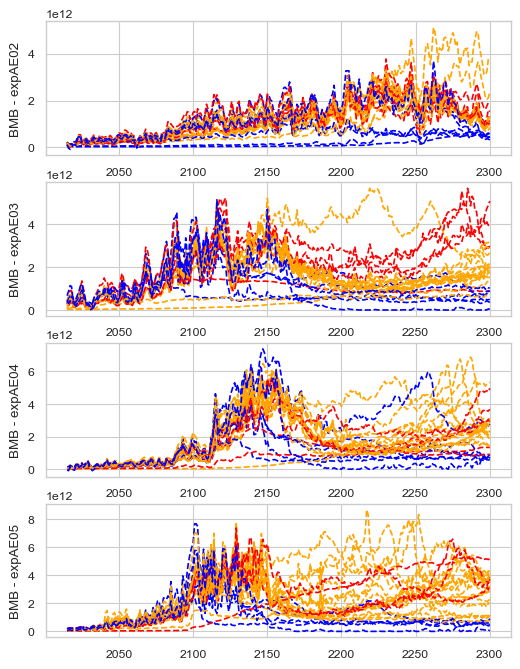

In [235]:
colors = ['blue','green','orange','red']
f,ax2 = plt.subplots(4,1,figsize = (6,8))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,exp in enumerate(expnames):
    ax= ax2[i]
    xmi = df_ms_ross[df_ms_ross.Experiment == exp].Ross.values[no_vuw]
    
    
   
    xmi2 = 100+df_iareafl2300_change_ross[df_iareafl2300_change_ross.Experiment == exp].Ross.values[no_vuw]  
    
    
    xm = xmi.copy()*xmi2.copy()


    
    
    x_n = xm-xm.mean()
    x_n = x_n/x_n.std()
    mask = x_n > x_n.std()
    mask_min = x_n <= -x_n.std()
    
    mask_mid_low = (x_n <= 0) & ~mask_min
    mask_mid_high = (x_n > 0) & ~mask
    
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid_low = xm[mask_mid_low]
    xm_mid_high = xm[mask_mid_high]
    
    
    
    xm_mid = xm[mask_mid]
 
    for j,ms_model1 in enumerate(xmi):
        ms_model2 = xmi2[j]
        ms_model =ms_model1*ms_model2
        #group the ms in a group
        Model = Models[j]
        df_model = df_ms_ross[df_ms_ross.Model == Model]
      
        if ms_model >= xm_high.min():
            cat = 3
            color =colors[3]
           
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
       
        else:
            cat = 2
            color =colors[2]
        

            
        df_pth =  df_model[ df_model.Experiment == exp]
        d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
#         d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
        y = 0
        area = 0
        for key  in regions_keys["Ross"]:
            melt = factor *d[f'shelfmelt{key}'].values
            y = y+melt
            

           
           
       
        ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i].set_ylabel(f'BMB - {exp}')



In [243]:
xmi3

array([ 4.56757807,  7.90320028,  8.62951011,  7.65782216,  6.28905982,
        6.35657244,  5.17521637,  4.64329368,  5.8704166 ,  6.93193254,
        4.7730717 ,  5.98609748,  6.90087715,  5.04063406,  5.01715501,
        5.9760372 ,  6.54397994,  5.51971197,  9.66717565,  9.05123278,
        8.80702716, 10.56032345,  5.59027495,  5.04482442,  8.37226794,
               nan])

#### now inlcude TF!!!

In [32]:
colors = ['blue','green','orange','red']
f,ax2 = plt.subplots(4,1,figsize = (6,8))
no_vuw = df_best.parameterization != 'Lin'
Models = df_best.Model.values[no_vuw]


for i,exp in enumerate(expnames):
    ax= ax2[i]
    xmi = df_ms_ross[df_ms_ross.Experiment == exp].Ross.values[no_vuw]
    
    
   
    xmi2 = 100+df_iareafl2300_change_ross[df_iareafl2300_change_ross.Experiment == exp].Ross.values[no_vuw]  
    xmi3= df_tf2300_ross[df_tf2300_ross.Experiment == exp].Ross.values[no_vuw]
    
    xm = xmi.copy()*xmi2.copy()*xmi3.copy()


    
    
    x_n = xm-np.nanmean(xm)
    x_n = x_n/np.nanstd(x_n)
    mask = x_n > np.nanstd(x_n)
    mask_min = x_n <= -np.nanstd(x_n)
    
    mask_mid_low = (x_n <= 0) & ~mask_min
    mask_mid_high = (x_n > 0) & ~mask
    
#     print(mask_min.sum())

    mask_mid =  ~mask & ~mask_min
    xm_high = xm[mask]
    xm_low = xm[mask_min]
    xm_mid_low = xm[mask_mid_low]
    xm_mid_high = xm[mask_mid_high]
    
    
    
    xm_mid = xm[mask_mid]
 
    for j,ms_model1 in enumerate(xmi):
        ms_model2 = xmi2[j]
        ms_model3 = xmi3[j]
        
        ms_model =ms_model1*ms_model2*ms_model3
        #group the ms in a group
        Model = Models[j]
        df_model = df_ms_ross[df_ms_ross.Model == Model]
      
        if ms_model >= xm_high.min():
            cat = 3
            color =colors[3]
           
        elif (len(xm_low)>0) and (ms_model <= xm_low.max()):
            cat = 0
            color =colors[0]
       
        else:
            cat = 2
            color =colors[2]
        

            
        df_pth =  df_model[ df_model.Experiment == exp]
        d = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
#         d_area = xr.open_dataset(df_pth.Path.values[0],decode_times=False)
            
        y = 0
        area = 0
        for key  in regions_keys["Ross"]:
            melt = factor *d[f'shelfmelt{key}'].values
            y = y+melt
            

           
           
       
        ax.plot(d.time.values,y, color = color,linestyle = '--' ,label = Model)
                
                
    ax2[i].set_ylabel(f'BMB - {exp}')



In [33]:
plt.scatter(np.arange(len(x_n)),x_n)
plt.scatter(np.arange(len(x_n))[mask],x_n[mask],color = 'red')
plt.scatter(np.arange(len(x_n))[mask_min],x_n[mask_min],color = 'black')
plt.scatter(np.arange(len(x_n))[mask_mid_low],x_n[mask_mid_low],color = 'green')
plt.scatter(np.arange(len(x_n))[mask_mid_high],x_n[mask_mid_high],color = 'orange')

In [34]:
plt.scatter(np.arange(len(x_n)),xm)
plt.scatter(np.arange(len(x_n))[mask],xm[mask],color = 'red')
plt.scatter(np.arange(len(x_n))[mask_min],xm[mask_min],color = 'black')
plt.scatter(np.arange(len(x_n))[mask_mid_low],xm[mask_mid_low],color = 'green')
plt.scatter(np.arange(len(x_n))[mask_mid_high],xm[mask_mid_high],color = 'orange')

In [108]:
col

'FilchnerRonne'

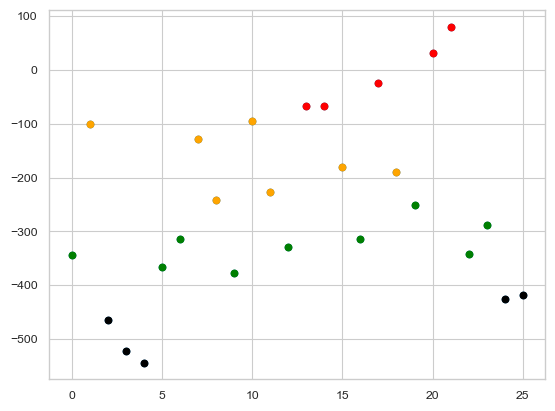

In [95]:
plt.scatter(np.arange(len(x_n)),xm)
plt.scatter(np.arange(len(x_n))[mask],xm_high,color = 'red')
plt.scatter(np.arange(len(x_n))[mask_min],xm_low,color = 'black')
plt.scatter(np.arange(len(x_n))[mask_mid_low],xm_mid_low,color = 'green')
plt.scatter(np.arange(len(x_n))[mask_mid_high],xm_mid_high,color = 'orange')